In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

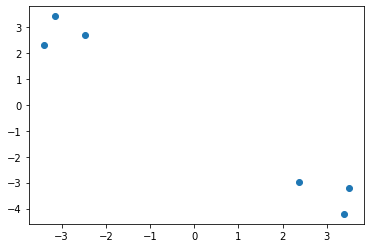

In [41]:
# toy example
X = np.zeros((6,2))
X[0:3] = 0.5 * np.random.randn(3,2) + [-3,3]
X[3:6] = 0.5*np.random.randn(3,2) + [3,-3]

plt.scatter(X[:,0],X[:,1])

**Step 1:** make each point its own cluster

In [26]:
k= X.shape[0]
clusters = np.arange(k)
clusters

array([0, 1, 2, 3, 4, 5])

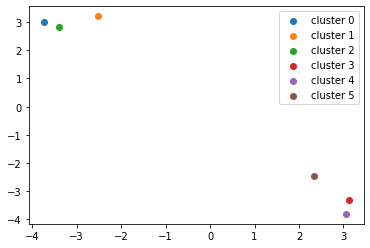

In [27]:
# plot clusters

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1], label = 'cluster ' +str(i))
    plt.legend()

**Step 2:** merge the two 'closest' clusters. We need to define a "cluster distance function" (linkage function).

Several options: Several options:

- centroid linkage: distance between two clusters is the distance between their centers (means)

- single linkage: distance between two clusters is the smallest distance between two points in each cluster

- complete linkage: distance between two clusters is the largest distance between two points in each cluster

- average linkage: distance between two clusters is the average distance between two points in each cluster

We'll implement "simple linkage"

In [28]:
# compute distance

dist = pairwise_distances(X)

# put infinity on diagonals

np.fill_diagonal(dist,np.inf)

dist 

array([[       inf, 1.23090895, 0.38390689, 9.33277887, 9.61629902,
        8.17019244],
       [1.23090895,        inf, 0.96967119, 8.62491187, 8.94999515,
        7.45534699],
       [0.38390689, 0.96967119,        inf, 8.95701475, 9.24413351,
        7.79333494],
       [9.33277887, 8.62491187, 8.95701475,        inf, 0.48038278,
        1.16962739],
       [9.61629902, 8.94999515, 9.24413351, 0.48038278,        inf,
        1.52779294],
       [8.17019244, 7.45534699, 7.79333494, 1.16962739, 1.52779294,
               inf]])

In [29]:
# find the closest clusters
i,j = np.unravel_index((np.argmin(dist)),(k,k))
# reorder the pair (i,j) so that j>i (symmetric matrix)

i,j = np.sort([i,j])

In [30]:
clusters[clusters==j]=i
clusters[clusters>j] -= 1

k-=1

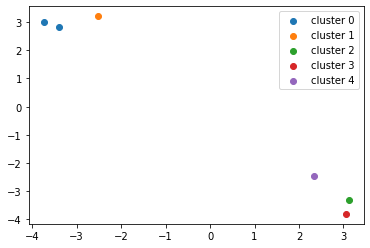

In [31]:
# plot clusters

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1], label = 'cluster ' +str(i))
    plt.legend()

In [32]:
# distance from cluster i to the other clusters
dist[i] = np.minimum(dist[i],dist[j])
dist[:,i] = dist[i]
dist[i,i] = np.inf
#remove row and column j
dist = np.delete(dist, j , axis = 0)
dist = np.delete(dist, j, axis = 1)

In [37]:
# repeat 
i,j = np.unravel_index(np.argmin(dist),(k,k))

i, j = np.sort([i,j])
clusters[clusters==j]=i
k -=1
clusters[clusters>j] -=1
dist[i] = np.minimum(dist[i],dist[j])
dist[:,i] = dist[i]
dist[i,i]=np.inf
dist = np.delete(dist,j,axis = 0)
dist = np.delete(dist,j,axis = 1)

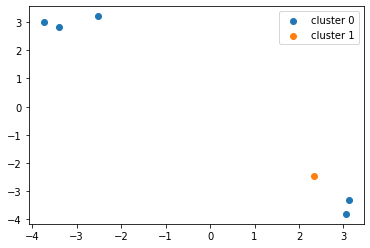

In [38]:
# plot clusters

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1], label = 'cluster ' +str(i))
    plt.legend()

In [44]:
def hierarchical_clustering(X,n_clusters):
    from sklearn.metrics import pairwise_distances
    
    m,n = X.shape
    
    dist = pairwise_distances(X)
    np.fill_diagonal(dist,np.inf)
    k=m
    clusters = np.arange(k)
    
    while k>n_clusters:
        # find closest clusters
        i, j = np.unravel_index(np.argmin(dist),(k,k))
        i,j = np.sort([i,j]) # reorder the pair (i,j) so that  j>i
        
        # merge clusters
        clusters[clusters==j]=i

        # rename clusters
        clusters[clusters>j] -= 1
        
        # recompute distance from the new cluster i to the remaining clusters'
        dist[i] = np.minimum(dist[i],dist[j]) # 
        dist[:,i] = dist[i] # distance_clusters matrix is symmetric
        dist[i,i]= np.inf # set the distance from cluster i to itself to infinity
            
        # remove row j and column j from distance_clusters matrix
        dist = np.delete(dist,j,0) # remove row j
        dist = np.delete(dist,j,1) # remove column j
        
    
        # reduce number of clusters
        k = k-1

    return clusters

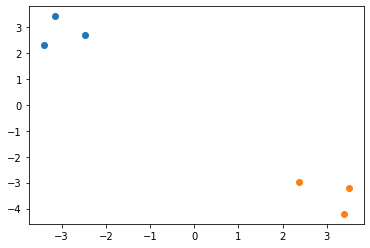

In [45]:
#check that it works
k = 2
clusters = hierarchical_clustering(X,n_clusters=k)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])

## k-means vs hierarchical clustering

In [46]:
def kmeans(X,k,max_iterations=1000):
    from sklearn.metrics import pairwise_distances
    # initialize iteration counter
    it = 0
    repeat = True
    
    # number of datapoints
    m = X.shape[0] 
    
    # initialization
    means = X[np.random.choice(m,k,replace=False)] 
    dist = pairwise_distances(X,means)
    clusters = np.argmin(dist, axis=1)
 
    
    while repeat and it<max_iterations:
        
        # update means; # if a cluster has no data points associated with it, replace it with a random data point
        means = np.array([np.mean(X[clusters==i], axis=0) 
                          if np.sum(clusters==i)!=0
                          else  X[np.random.randint(m)]
                          for i in range(k)])
        
        # update clusters
        dist = pairwise_distances(X,means)
        new_clusters = np.argmin(dist, axis=1)
        
        # check if the new clusters are equal to the previous clusters
        if np.sum(clusters!=new_clusters)==0: 
            repeat = False
        clusters = new_clusters
                
        it += 1 # increment iteration counter by 1
    
    return clusters, means

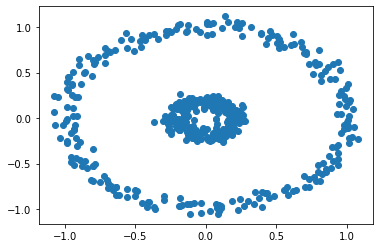

In [47]:
from sklearn.datasets import make_circles
X,y = make_circles(n_samples = 500, noise = 0.05, factor=0.2)
plt.scatter(X[:,0],X[:,1])

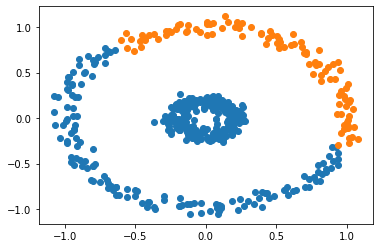

In [48]:
clusters, means = kmeans(X,k=2,)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])

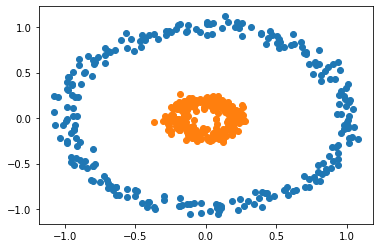

In [50]:
clusters = hierarchical_clustering(X,n_clusters=2)

for i in range(k):
    plt.scatter(X[clusters==i,0],X[clusters==i,1])